In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
import torch
import re
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ GPU kullanılıyor")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("⚠️ GPU yok, CPU kullanılıyor")

✅ GPU kullanılıyor
GPU: Tesla T4


In [ ]:
df = pd.read_csv("articles_clean.csv")
df.head()

,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


In [ ]:
df["combined_text"].iloc[0]

'i̇nsansız hava araçları için manyetik rezonans kuplaj ile şarj i̇stasyonu tasarımı i̇nsansız hava araçları (i̇ha) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. gerçekleştirilen bu çalışmada, i̇ha’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. devre tasarımlarının analizleri, matlab ve pspice programları sayesinde gerçekleştirilmiştir. ayrıca; şarj cihazında kullanılan bobinler, ansys maxwell programı kullanılarak tasarlanmıştır. tasarlanan şarj istasyonu ile 12 cm’den 3w gücündeki lityum bataryalar şarj edilmiştir. tasarlanan sistem ile i̇ha’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır. insansız hava aracı (i̇ha), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.'

### SBERT (Sentence-BERT)
Bu çalışmada **SBERT**, cümle ve dokümanlar arası anlamsal benzerliği ölçmek için kullanılan bir modeldir.  
Model, Hugging Face üzerinde **`paraphrase-multilingual-MiniLM-L12-v2`** adıyla yayınlanmıştır.

**Temel özellikler:**
- 🌍 Çok dilli yapıdadır (Türkçe dahil)  
- 🧠 Cümle/doküman düzeyinde embedding üretimi için özel olarak eğitilmiştir  
- 📐 Cosine similarity ile doğrudan uyumludur  
- ⚡ MiniLM mimarisi sayesinde hızlı ve hafiftir  

**BERTurk’ten farkı (kısaca):**
- BERTurk token-level çıktılar üretir, SBERT ise **doğrudan cümle embedding’i** üretir  
- SBERT, **alakasız metinlere yüksek benzerlik verme sorununu** daha az yaşatır  

Bu model, özellikle:
- Metin benzerliği (semantic similarity)
- Semantic search
- Doküman eşleştirme

gibi görevlerde yaygın olarak kullanılmaktadır.

In [ ]:
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
model = SentenceTransformer(model_name, device=device)

print(f"✅ Model loaded: {model_name}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded: paraphrase-multilingual-MiniLM-L12-v2


Token indices sequence length is longer than the specified maximum sequence length for this model (205 > 128). Running this sequence through the model will result in indexing errors


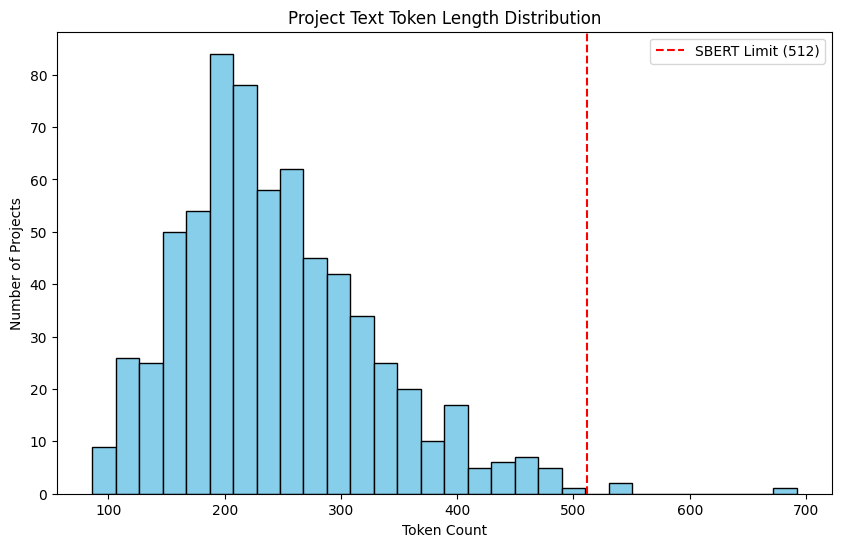

Ortalama token sayısı: 244.4069069069069
512 token'ı geçen proje sayısı: 3


In [ ]:
# Her projenin model tarafından kaç 'token' olarak algılandığını hesaplar
df['token_counts'] = df['combined_text'].apply(lambda x: len(model.tokenizer.encode(x)))

# Token dağılımını görselleştirerek 512 sınırına yakınlığı kontrol eder
plt.figure(figsize=(10, 6))
plt.hist(df['token_counts'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=512, color='red', linestyle='--', label='SBERT Limit (512)')
plt.title('Project Text Token Length Distribution')
plt.xlabel('Token Count')
plt.ylabel('Number of Projects')
plt.legend()
plt.show()

# Veri kaybı olup olmadığını anlamak için özet istatistikler
print(f"Ortalama token sayısı: {df['token_counts'].mean()}")
print(f"512 token'ı geçen proje sayısı: {(df['token_counts'] > 512).sum()}")

In [ ]:
def get_embeddings(text):
    """
    Tek bir metin veya metin listesi için SBERT embedding üretir.
    Dönüş tipi: NumPy Array (float32)
    """
    # model.encode işlemi pooling ve GPU transferini otomatik yönetir
    return model.encode(text, convert_to_numpy=True, show_progress_bar=False)

# Pandas işlemlerine görsel ilerleme çubuğu (tqdm) ekler
tqdm.pandas()
print("🚀 SBERT embedding süreci başlatılıyor...")

# Tüm projeler için vektör üretir ve liste formatına çevirir
df["embedding"] = df["combined_text"].progress_apply(lambda x: get_embeddings(x).tolist())

print("\n✅ Embedding işlemi başarıyla tamamlandı.")
print(f"Toplam Kayıt: {len(df)}")
print(f"Vektör Boyutu: {len(df['embedding'].iloc[0])}")

🚀 SBERT embedding süreci başlatılıyor...


100%|██████████| 666/666 [00:08<00:00, 80.05it/s]


✅ Embedding işlemi başarıyla tamamlandı.
Toplam Kayıt: 666
Vektör Boyutu: 384


In [ ]:
df.head()

,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text,token_counts,embedding
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...,205,"[-0.24780148267745972, 0.4190647304058075, -0...."
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,188,"[0.028746966272592545, 0.10190483927726746, -0..."
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,181,"[-0.32909321784973145, 0.08239515125751495, -0..."
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac...",114,"[0.028681356459856033, 0.12012267857789993, -0..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,185,"[0.0043609775602817535, 0.1276913583278656, -0..."


### Kosinüs Benzerliği (Cosine Similarity) ile Anlamsal Karşılaştırma

Kosinüs benzerliği ($\text{Cosine Similarity}$), iki vektör arasındaki açının kosinüsünü hesaplayarak
vektörlerin **yönel benzerliğini** ölçen bir metriktir. Bu yöntem, vektörlerin büyüklüğünden
bağımsız olarak anlamsal yakınlığı değerlendirmesi nedeniyle metin benzerliği problemlerinde
yaygın olarak kullanılmaktadır.

Matematiksel olarak iki vektör $\mathbf{A}$ ve $\mathbf{B}$ arasındaki kosinüs benzerliği şu şekilde tanımlanır:

$$
\text{similarity} = \cos(\theta) =
\frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}
$$

Bu çalışmada:
- Metinler **SBERT** modeli kullanılarak 384 boyutlu embedding vektörlerine dönüştürülmüştür.
- Sorgu metni ile veri kümesindeki her bir kayıt arasındaki anlamsal benzerlik,
  kosinüs benzerliği yardımıyla hesaplanmıştır.
- Elde edilen skorlar **[−1, 1]** aralığında olup, değerin 1’e yaklaşması metinlerin
  anlamsal olarak daha benzer olduğunu göstermektedir.

Sonuç olarak, en yüksek kosinüs benzerliği skoruna sahip kayıtlar,
sorgu metnine anlamsal açıdan en yakın projeler olarak raporlanmıştır.

In [ ]:
def clean_text(text):
    # Metni temizleme
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[#%&*_=+<>]", "", text)
    return text.strip()

# Kullanıcıdan gelen ham veriler
raw_query_title = "Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi"

raw_query_abstract = (
    "Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak "
    "birebir muharebeler için otonom savunma algoritması geliştirilmiştir. "
    "Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda "
    "saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. "
    "Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan "
    "dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş "
    "manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı "
    "bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile "
    "algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir."
)

raw_query_keywords = "bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları."

# Metinleri birleştirme ve modele uygun vektöre çevirme
query_text = f"{clean_text(raw_query_title)} {clean_text(raw_query_abstract)} {clean_text(raw_query_keywords)}"
query_vector = model.encode(query_text, convert_to_numpy=True).astype(np.float32)

# Mevcut veri kümesini karşılaştırma için hazırlama
corpus_embeddings = np.array(df["embedding"].tolist(), dtype=np.float32)

# Kosinüs benzerliği hesaplama
similarity_scores = util.cos_sim(query_vector, corpus_embeddings)[0]

# Sonuçları raporlama ve benzerlik skoruna göre sıralama
df["similarity_score"] = similarity_scores.detach().cpu().numpy()
top_results = df.sort_values(by="similarity_score", ascending=False)

# En benzer ilk 5 sonuç
print("\n--- Anlamsal Arama Sonuçları ---")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].head(5))

print("\n", "*"*215)

# En az benzer son 5 sonuç
print("\n--- En Az Benzer Sonuçlar ---")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].tail(5))


--- Anlamsal Arama Sonuçları ---


,Year,Title_TR,Abstract_TR,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi,"Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir.",1.000000
478,2023-2024,Hava Muharebesinde Bulanık Mantık ile Karar,"Hava muharebeleri, saldırı ve savunma manevralarının dengeli bir şekilde yapıldığı karmaşık stratejilere dayanmaktadır. Bu projede, hava muharebelerinde otonom karar alma yeteneğini artırmak için oyun teorisi, bulanık mantık ve dinamik programlama gibi ileri düzey tekniklerin birleşiminden oluşan bir algoritma geliştirilmesi hedeflenmektedir. Geliştirilecek olan algoritma, hava muharebelerinde bilinçli kararlar alabilen otonom sistemlerin geliştirilmesine odaklanmaktadır. Bu amaçla, geliştirilen algoritma simülasyon ortamında test edilecek ve başarı oranı ölçülecektir. Algoritmanın performansı, çeşitli simüle edilmiş muharebe senaryoları üzerinde test edilerek değerlendirilecektir. Başarı metrikleri arasında, misyon başarı oranları, kaynak kullanım verimliliği ve değişen ortamlara uygunluk gibi faktörler bulunacaktır. Bu çalışma, hava muharebelerinde otonom sistemlerin karar alma yeteneğini artırmak için kullanılabilecek yeni ve etkili bir yaklaşım sunmayı amaçlamaktadır.",0.850814
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar Kullanılarak Karar Verme Algoritmalarının Gerçeklenmesi ve Analizi,"Hava muharebelerinde otonominin giderek yaygın- laşmasıyla birlikte görevleri yüksek başarı oranlarıyla gerçekleş- tirecek uçuş algoritmalarının önemi her geçen gün artmaktadır. Bu çalışmada ise bulanık mantık destekli karar verme algoritma- ları ile otonom hava muharebelerinde meydana gelebilecek du- rumlar için bulanık mantık kural tabanı ile MATLAB kullanıla- rak uçuş senaryolarının simülasyon ortamında gerçeklenmesi amaçlanmıştır. Uçakların it dalaşındaki etkinliği değerlendiril- mektedir. Algoritma, hedef uçak hareketine bağlı olarak bulanık mantık kural tabanına göre uygun referans değerlerini üreterek saldırı manevraları gerçekleştirmektedir.",0.807760
479,2023-2024,"Hava Muharebesinde Oyun Teorisi, Bulanık Mantık ve Dinamik Programlama Kullanarak Karar Verme Algoritmasının Uygulanması ve Analizi","Bu çalışmada hava muharebesinde askeri pilotların başarı oranını artırmak için eğitim amaçlı kullanılmak üzere hava araçlarının aerodinamik yapıları göz önünde bulundurularak Unity oyun motorunda simülasyon ortamı hazırlanmıştır. Bu ortamda eğitim görmekte olan pilotlarla yarışacak, düşman pilot olarak görev alacak, pilotların manevralarını analiz ederek sürekli kendi stratejisini belirleyecek bir yapay zekâ modeli geliştirilmiştir. Yapay zekâ modelinin tasarımında derin öğrenme ve takviyeli öğrenme tekniklerini birleştiren Derin Q Ağları (DQN) kullanılmıştır. Bu alanda belirttiğimiz tekniklerle, geliştirdiğimiz eğitim simülasyon ortamının bir araya getirilmesi çalışmamızın temel katkısıdır. Geliştirilen simülasyon sistemi ve DQN tabanlı yapay zekâ modeli, hava muharebesi eğitimlerinde kullanılacak bir eğitim aracının temellerini oluşturmuştur.",0.779814
573,2023-2024,Otomatik Arazi Çarpışma Önleme Sistemi Algoritması Tasarımı,"Bu çalışma, pilotun kontrolündeki uçağın pilotun farkında olmadığı bir durumda bulunduğu yerdeki dağ, bina gibi doğal ya da insan yapımı engellere çarpacağını sahip olduğu arazi bilgisini kullanarak tespit edip uçağa otomati


 ***********************************************************************************************************************************************************************************************************************

--- En Az Benzer Sonuçlar ---


,Year,Title_TR,Abstract_TR,similarity_score
395,2023-2024,Alüminyum Tozu Eklentili Hibrit Kompozitlerin Yapısal ve Elektriksel Değerlendirilmesi,"Bu çalışmada, karbon fiber kompozit malzemelere AlSi10Mg alüminyum cüruf tozu eklenmesinin malzemenin mekanik ve elektriksel özelliklerine etkisi deneysel olarak incelenmiştir. Deneylerde, twill 2x2 200 gr/m2’lik kumaşlar kullanılmış, matris malzemesi olarak da epoksi reçine tercih edilmiştir. Alüminyum tozları, reçinenin içerisine kütlesel olarak %5, %10 ve %15 oranlarında eklenmiştir. Elektriksel iletkenlik, bonding metre ile ölçülmüş ve çekme testleri ISO 527-4:2023 standardına göre gerçekleştirilmiştir. Hazırlanan numunelerin elektriksel iletkenlik ölçümleri sonucunda, elektrik iletkenliğinin referans numuneye oranla %43 oranında artığı gözlemlenmiştir. Sonuçlar, karbon fiber kompozit malzemelere alüminyum tozu eklenmesinin malzemenin çekme dayanımı ve elastisite modülünde azalmaya yol açmasına rağmen bu azalmanın kayda değer miktarda olmadığını göstermiştir.",0.059952
540,2023-2024,Kompozit Yapıştırma Bağlantılarında Optimum Parametrelerin Belirlenmesi Determination of Optimum Parameters in Adhesively,"Bu çalışmanın amacı yapıştırıcıyla birleştirilmiş karbon fiber kompozit bağlantılarda, yapıştırıcı ve yapıştırılan malzeme kalınlığı ile bindirme uzunluğunun etkisini deneysel ve yapay sinir ağları ile incelemek ve optimum parametreleri belirlemektir. Bu kapsamda, üç farklı yapıştırıcı kalınlığı (0,15, 0,30 ve 0,45 mm), üç farklı yapıştırılan malzeme kalınlığı (2, 3 ve 4 mm) ve üç farklı bindirme uzunluğu (12,5, 25 ve 37,5 mm) parametreleri dikkate alınarak tek tesirli kompozit yapıştırma bağlantıları üretilmiştir. Bağlantıların mekanik performansını etkileyen bu parametrelerin belirlenmesi amacıyla, üretilen bağlantı numuneleri çekme testine tabi tutulmuş olup, hasar yükü ve yer değiştirme değerleri belirlenmiştir. Ayrıca, bu çalışmada, farklı parametrelerde üretilen yapıştırıcıyla birleştirilmiş kompozit bağlantıların hasar yükü ve yer değiştirme değerlerini tahmin etmek için ileri beslemeli çok katmanlı bir yapay sinir ağı kullanılmıştır. Çalışmadan elde edilen bulgular neticesinde, bindirme uzunluğu, yapıştırıcı ve malzeme kalınlığını değişimiyle hasar yükünün nasıl etkilendiği detaylı bir şekilde ortaya konulmuştur. Ayrıca, kompozit yapıştırma bağlantıları için optimum parametreler tayin edilmiştir.",0.059874
635,2023-2024,Ti6Al4V Esaslı Malzeme ile Eklemeli Olarak Üretilen Ürünlerde Mikroyapı-Mekanik Özellik (Yorulma ve Hasar Mekanizması) İlişkisi,"Eklemeli imalat yöntemlerinden EBM (Electron Beam Melting) ve SLM (Selective Laser Melting) yöntemleriyle üretilen Ti6Al4V alaşımında üretim yöntemi sebebiyle kalıntı gerilmeler meydana gelmektedir. Bu kalıntı gerilmeleri ortadan kaldırmak için kalıntı gerilme giderme ısıl işlemi uygulanmıştır. Yapıdaki kalıntı gerilmelerin miktarını ve özelliklerini belirlemek için indentasyon yöntemi uygulanmış ve Suresh ve Swadener yöntemleriyle hesaplamalar yapılmıştır. Ti6Al4V alaşımının mekanik özelliklerini geliştirmek için çeşitli ısıl işlemler uygulanmıştır. Mikroyapı ve mekanik özelliklerdeki değişiklikleri gözlemlemek için mikroyapı karakterizasyonu, sertlik ve nanoindentasyon yorulma ölçüm teknikleri uygulanmıştır. Malzemedeki değişiklikler, geleneksel yöntemlere göre birçok avantajı olan nanoindentasyon yorulma testi yöntemiyle belirlenmiştir. Tercih edilen bu yorulma testi yöntemi ile geleneksel yorulma testleri arasında bir korelasyonun kurulup kurulamayacağı belirlenmiştir. SLM ve EBM yöntemlerinin mikroyapı ve mekanik özellikleri arasındaki farklar ortaya çıkarılmıştır.",0.053075
380,2022-2023,Yapıştırıcı ile Birleştirilen Kompozitlerde Farklı Parametrelerin Kayma Dayanımına Etkisinin İncelenmesi,"Bu çalışmada yapıştırıcı ile birleştirilmiş karbon fiber takviyeli kompozit plakaların tek bindirmeli kayma dayanımları yapıştırıcı kalınlığı, kompozit kalınlığı ve fiber yönlenmesi gibi değişen parametrelerle kıyaslanmıştır. Mukavim bir

In [ ]:
df["combined_text"].iloc[2]

'hava muharebesinde otonom savunma algoritmasının geliştirilmesi bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. matlab/simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir. bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları.'

In [ ]:
df["embedding"].iloc[2]

[-0.32909321784973145,
 0.08239515125751495,
 -0.3888929486274719,
 -0.14813768863677979,
 -0.02531811222434044,
 0.05689551681280136,
 0.19944441318511963,
 -0.04115884751081467,
 -0.12499479949474335,
 0.24509544670581818,
 0.20768754184246063,
 0.24621082842350006,
 0.15857571363449097,
 -0.0663112923502922,
 0.05459672212600708,
 0.19837862253189087,
 -0.0924990251660347,
 0.131642147898674,
 0.0877341479063034,
 -0.09206577390432358,
 -0.03810480237007141,
 0.05831083655357361,
 0.09825344383716583,
 0.0801849216222763,
 -0.2903820872306824,
 0.05161430686712265,
 0.05764622241258621,
 0.010867811739444733,
 0.04775428771972656,
 -0.17383088171482086,
 0.24762482941150665,
 -0.007367197889834642,
 0.320025771856308,
 -0.07458528131246567,
 -0.16743353009223938,
 -0.12560319900512695,
 0.03752945363521576,
 0.09920908510684967,
 -0.11698301136493683,
 -0.19615435600280762,
 -0.23804542422294617,
 0.01382808294147253,
 0.18593591451644897,
 -0.1578180491924286,
 0.03154357522726059,

In [ ]:
top_results.head()

,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text,token_counts,embedding,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,181,"[-0.32909321784973145, 0.08239515125751495, -0...",1.000000
478,2023-2024,Hava Muharebesinde Bulanık Mantık ile Karar,"Hava muharebeleri, saldırı ve savunma manevral...","hava muharebesi, bulanık mantık, dinamik progr...",hava muharebesinde bulanık mantık ile karar,"hava muharebeleri, saldırı ve savunma manevral...","hava muharebesi, bulanık mantık, dinamik progr...",hava muharebesinde bulanık mantık ile karar ha...,239,"[-0.1372779905796051, 0.13404901325702667, -0....",0.850814
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar K...,Hava muharebelerinde otonominin giderek yaygın...,"otonom hava muharebeleri, bulanık mantık, kara...",otonom hava muharebelerinde bulanık metodlar k...,hava muharebelerinde otonominin giderek yaygın...,"otonom hava muharebeleri, bulanık mantık, kara...",otonom hava muharebelerinde bulanık metodlar k...,190,"[-0.09329770505428314, 0.0010931906290352345, ...",0.807760
479,2023-2024,"Hava Muharebesinde Oyun Teorisi, Bulanık Mantı...",Bu çalışmada hava muharebesinde askeri pilotla...,"Takviyeli Öğrenme, Oyun Teorisi, Simülasyon, D...","hava muharebesinde oyun teorisi, bulanık mantı...",bu çalışmada hava muharebesinde askeri pilotla...,"takviyeli öğrenme, oyun teorisi, simülasyon, d...","hava muharebesinde oyun teorisi, bulanık mantı...",235,"[-0.0767216682434082, 0.18858136236667633, -0....",0.779814
573,2023-2024,Otomatik Arazi Çarpışma Önleme Sistemi Algorit...,"Bu çalışma, pilotun kontrolündeki uçağın pilot...","Auto-GCAS, CFIT, simülasyon tabanlı geliştirme...",otomatik arazi çarpışma önleme sistemi algorit...,"bu çalışma, pilotun kontrolündeki uçağın pilot...","auto-gcas, cfit, simülasyon tabanlı geliştirme...",otomatik arazi çarpışma önleme sistemi algorit...,306,"[-0.1540226936340332, -0.06042413413524628, -0...",0.762122


### Sentence-BERT (SBERT) ile Anlamsal Benzerlik Analizi Sonuçları

Bu çalışmada, Türkçe teknik metinler üzerinde anlamsal benzerlik analizi gerçekleştirmek amacıyla **Sentence-BERT (SBERT)** modeli kullanılmıştır. Her bir çalışmanın başlık, özet ve anahtar kelimelerinden oluşan birleşik metinler embedding vektörlerine dönüştürülmüş ve **cosine similarity** metriği ile benzerlik hesaplanmıştır.

Elde edilen sonuçlar incelendiğinde, sorgu metniyle **aynı problem alanına** (hava muharebesi, otonom sistemler, karar verme algoritmaları) sahip çalışmaların yüksek benzerlik skorları (≈0.75–0.85) ile üst sıralarda yer aldığı görülmüştür. Özellikle otonom hava muharebesi, bulanık mantık ve karar verme algoritmalarını ele alan çalışmalar semantik olarak güçlü bir örtüşme göstermektedir.

Buna karşılık, malzeme bilimi ve kompozit yapılar gibi **konu dışı** çalışmaların çok düşük benzerlik skorları (≈0.03–0.06) aldığı gözlemlenmiştir. Bu durum, SBERT modelinin anlamsal ayrım gücünün yüksek olduğunu ve alan içi–alan dışı çalışmaları başarıyla ayırt edebildiğini göstermektedir.

Sonuç olarak, SBERT tabanlı embedding’lerin Türkçe teknik dokümanlar üzerinde **anlamsal arama ve literatür taraması** amaçlı etkin ve güvenilir bir şekilde kullanılabileceği değerlendirilmiştir.


In [ ]:
df_finally = df[["Year","Title_TR", "Abstract_TR","Keywords_TR","combined_text","embedding"]]

,Year,Title_TR,Abstract_TR,Keywords_TR,combined_text,embedding
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,"[-0.24780148267745972, 0.4190647304058075, -0...."
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,"[0.028746966272592545, 0.10190483927726746, -0..."
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"[-0.32909321784973145, 0.08239515125751495, -0..."
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac...","[0.028681356459856033, 0.12012267857789993, -0..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,"[0.0043609775602817535, 0.1276913583278656, -0..."


In [ ]:
with pd.option_context('display.max_colwidth', None):
    display(df_finally.head())

,Year,Title_TR,Abstract_TR,Keywords_TR,combined_text,embedding
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans Kuplaj ile Şarj İstasyonu Tasarımı,"İnsansız Hava Araçları (İHA) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. Gerçekleştirilen bu çalışmada, İHA’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. Devre tasarımlarının analizleri, Matlab ve PSpice programları sayesinde gerçekleştirilmiştir. Ayrıca; şarj cihazında kullanılan bobinler, ANSYS Maxwell programı kullanılarak tasarlanmıştır. Tasarlanan şarj istasyonu ile 12 cm’den 3W gücündeki lityum bataryalar şarj edilmiştir. Tasarlanan sistem ile İHA’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır.","insansız hava aracı (İHA), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.","i̇nsansız hava araçları için manyetik rezonans kuplaj ile şarj i̇stasyonu tasarımı i̇nsansız hava araçları (i̇ha) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. gerçekleştirilen bu çalışmada, i̇ha’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. devre tasarımlarının analizleri, matlab ve pspice programları sayesinde gerçekleştirilmiştir. ayrıca; şarj cihazında kullanılan bobinler, ansys maxwell programı kullanılarak tasarlanmıştır. tasarlanan şarj istasyonu ile 12 cm’den 3w gücündeki lityum bataryalar şarj edilmiştir. tasarlanan sistem ile i̇ha’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır. insansız hava aracı (i̇ha), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.","[-0.24780148267745972, 0.4190647304058075, -0.1480903923511505, -0.12749674916267395, 0.01036958396434784, -0.1952468752861023, 0.08669387549161911, 0.16015443205833435, -0.036684464663267136, 0.19514945149421692, 0.08621737360954285, 0.1315033733844757, 0.07061684131622314, 0.1346909999847412, 0.020039668306708336, 0.08086402714252472, 0.04942576214671135, -0.12026728689670563, 0.11686448007822037, 0.09867027401924133, 0.35314837098121643, 0.11679847538471222, -0.05995362251996994, 0.07459785044193268, -0.24679607152938843, 0.278298020362854, 0.01650134101510048, -0.0884704738855362, 0.025887547060847282, -0.22479459643363953, 0.10307228565216064, 0.2719670534133911, 0.17239916324615479, -0.12151766568422318, 0.024980053305625916, 0.1612502932548523, 0.154753640294075, -0.12259826809167862, -0.41382622718811035, -0.1670866310596466, -0.14528857171535492, -0.11534740030765533, 0.2569619417190552, -0.0729093998670578, -0.016834493726491928, 0.12508992850780487, 0.1134287565946579, -0.212184876203537, 0.12485824525356293, -0.15076276659965515, 0.2758665978908539, 0.05372178554534912, 0.02497299388051033, -0.2660320997238159, 0.10722368210554123, 0.07055235654115677, 0.15263280272483826, -0.10338287055492401, -0.3192386031150818, -0.3735363483428955, -0.10440032929182053, 0.10981900244951248, -0.11087139695882797, 0.09566584974527359, 0.030979149043560028, 0.08446812629699707, 0.1936360001564026, -0.043997544795274734, 0.385680228471756, -0.2854614555835724, -0.253818154335022, -0.18582719564437866, 0.15241077542304993, -0.1281718611717224, 0.04171857237815857, 0.2913128733634949, 0.03274758905172348, -0.02806515246629715, 0.07634130120277405, -0.04216795787215233, 0.16135747730731964, -0.20065924525260925, 0.038691356778144836, -0.09732368588447571, -0.029954882338643074, 0.2139088213443756, 0.023115133866667747, -0.14812985062599182, 0.13527105748653412, 0.0039973813109099865, -0.027107227593660355, -0.11705093085765839, -0.24509111046791077, 0.08411577343940735, -0.21413052082061768, -0.10358215868473053, -0.22180500626564026, -0.23556676506996155, -0.0044798096641898155, 0.2087615430355072, ...]"
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savunma ve Havacılık Sektörü Firmalarına Uygulanabilirliğinin İncelenmesi,"Savunma ve havacılık sanayinin rekabetçi koşulları ve iş geliştirme süreçlerinin 

In [ ]:
# Kaydetme
df_finally.to_pickle("tusas_liftup_embeddings.pkl")

In [ ]:
df_reloaded = pd.read_pickle("tusas_liftup_embeddings.pkl")
df_reloaded.head()

,Year,Title_TR,Abstract_TR,Keywords_TR,combined_text,embedding
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,"[-0.24780148267745972, 0.4190647304058075, -0...."
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,"[0.028746966272592545, 0.10190483927726746, -0..."
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"[-0.32909321784973145, 0.08239515125751495, -0..."
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac...","[0.028681356459856033, 0.12012267857789993, -0..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,"[0.0043609775602817535, 0.1276913583278656, -0..."


In [ ]:
df_reloaded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           666 non-null    object
 1   Title_TR       666 non-null    object
 2   Abstract_TR    666 non-null    object
 3   Keywords_TR    666 non-null    object
 4   combined_text  666 non-null    object
 5   embedding      666 non-null    object
dtypes: object(6)
memory usage: 31.3+ KB
